Projeto integrador


In [ ]:
#Importação das bibliotecas necessárias
import io
import pandas as pd
from google.colab import files
import seaborn as sns
import matplotlib.pyplot as plt

#Exemplo 1: leitura dos dados em excel - dados estruturados

In [ ]:
df = pd.read_csv('/content/Superstore.csv', encoding='latin1')

#imprimir os dados - dados estruturados de banco.

In [ ]:
print(df)

      Row ID        Order ID  Order Date   Ship Date       Ship Mode  \
0          1  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
1          2  CA-2016-152156   11/8/2016  11/11/2016    Second Class   
2          3  CA-2016-138688   6/12/2016   6/16/2016    Second Class   
3          4  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
4          5  US-2015-108966  10/11/2015  10/18/2015  Standard Class   
...      ...             ...         ...         ...             ...   
9989    9990  CA-2014-110422   1/21/2014   1/23/2014    Second Class   
9990    9991  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9991    9992  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9992    9993  CA-2017-121258   2/26/2017    3/3/2017  Standard Class   
9993    9994  CA-2017-119914    5/4/2017    5/9/2017    Second Class   

     Customer ID     Customer Name    Segment        Country             City  \
0       CG-12520       Claire Gute   Consumer  United 

#a) Qual é a estrutura do dataset? (Quantas linhas e colunas existem?)

In [ ]:
print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")

O dataset possui 9994 linhas e 21 colunas.


#b) Quais são os tipos de variáveis presentes? (Numéricas, categóricas, texto, etc.)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
df.select_dtypes('object').nunique()

,0
Order ID,5009
Order Date,1237
Ship Date,1334
Ship Mode,4
Customer ID,793
Customer Name,793
Segment,3
Country,1
City,531
State,49


#Exemplo 2: verificar quantas ocorrências na base de bancos é nula

In [ ]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


# Verificar duplicatas

In [ ]:
print(f"Total de linhas duplicadas: {df.duplicated().sum()}")

Total de linhas duplicadas: 0


# Convertendo as colunas de datas para datas

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])


#Quais são as estatísticas básicas das variáveis numéricas? (Média, mediana, mínimo, máximo, desvio padrão).


In [ ]:
numericas = df.select_dtypes(include=['int64', 'float64'])

superStore_media = numericas.mean()
superStore_mediana = numericas.median()
superStore_minimo = numericas.min()
superStore_maximo = numericas.max()
superStore_desvio = numericas.std()


print("Média:")
print(" ")
print(superStore_media)
print(" ")
print("Mediana:")
print(" ")
print(superStore_mediana)
print(" ")
print("Minimo:")
print(" ")
print(superStore_minimo)
print(" ")
print("Máximo:")
print(" ")
print(superStore_maximo)
print(" ")
print("Desvio padrão:")
print(" ")
print(superStore_desvio)
print(" ")

Média:
 
Row ID          4997.500000
Postal Code    55190.379428
Sales            229.858001
Quantity           3.789574
Discount           0.156203
Profit            28.656896
dtype: float64
 
Mediana:
 
Row ID          4997.5000
Postal Code    56430.5000
Sales             54.4900
Quantity           3.0000
Discount           0.2000
Profit             8.6665
dtype: float64
 
Minimo:
 
Row ID            1.000
Postal Code    1040.000
Sales             0.444
Quantity          1.000
Discount          0.000
Profit        -6599.978
dtype: float64
 
Máximo:
 
Row ID          9994.000
Postal Code    99301.000
Sales          22638.480
Quantity          14.000
Discount           0.800
Profit          8399.976
dtype: float64
 
Desvio padrão:
 
Row ID          2885.163629
Postal Code    32063.693350
Sales            623.245101
Quantity           2.225110
Discount           0.206452
Profit           234.260108
dtype: float64
 


#Existe uma relação entre variáveis numéricas? (Correlação entre idade e salário, por exemplo).

In [ ]:

numerical_df=df.select_dtypes(include=['int64', 'float64'])
correlacao = numerical_df.corr()
print(correlacao)

               Row ID  Postal Code     Sales  Quantity  Discount    Profit
Row ID       1.000000     0.009671 -0.001359 -0.004016  0.013480  0.012497
Postal Code  0.009671     1.000000 -0.023854  0.012761  0.058443 -0.029961
Sales       -0.001359    -0.023854  1.000000  0.200795 -0.028190  0.479064
Quantity    -0.004016     0.012761  0.200795  1.000000  0.008623  0.066253
Discount     0.013480     0.058443 -0.028190  0.008623  1.000000 -0.219487
Profit       0.012497    -0.029961  0.479064  0.066253 -0.219487  1.000000


# Como visualizar melhor os dados? (Histograma, boxplot, scatterplot, heatmap)

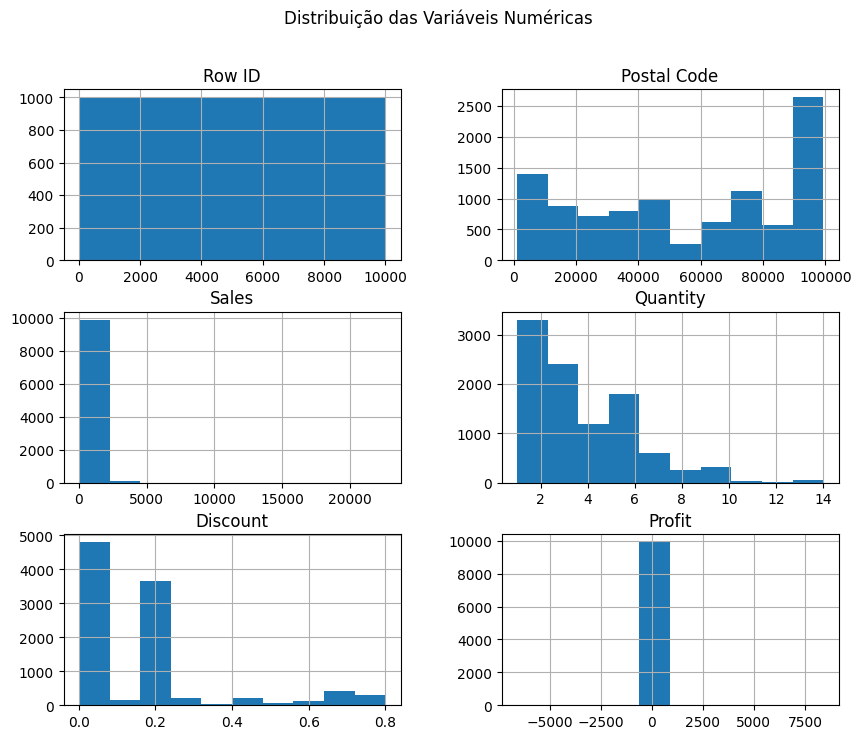

In [ ]:
numerical_df.hist(figsize=(10,8))
plt.suptitle('Distribuição das Variáveis Numéricas')
plt.show()

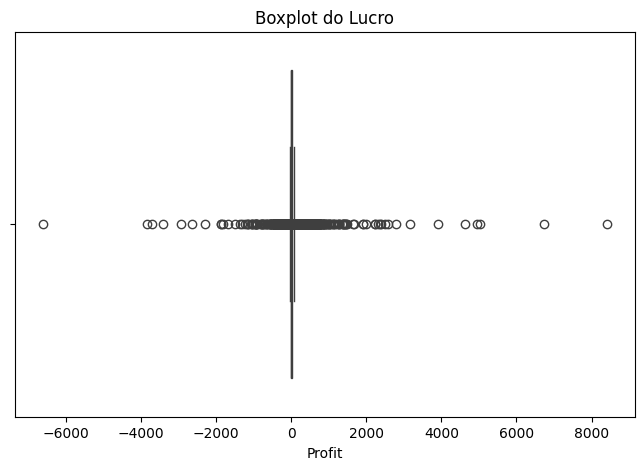

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Profit'])

plt.title('Boxplot do Lucro')

plt.show()

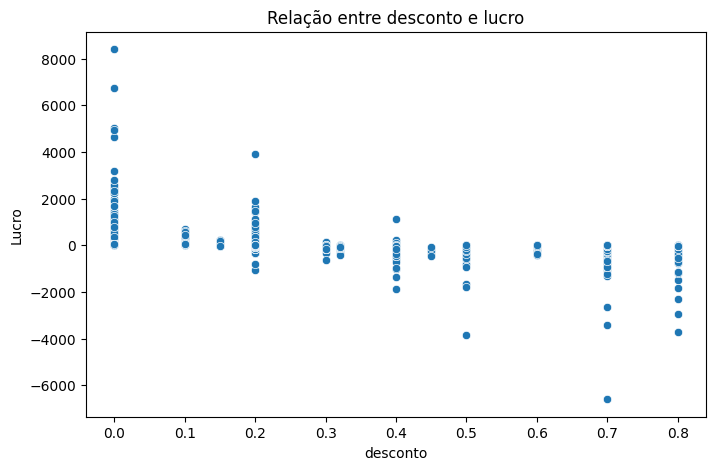

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount', y='Profit', data=df)

plt.title('Relação entre desconto e lucro')
plt.xlabel('desconto')
plt.ylabel('Lucro')

plt.show()

<Axes: >

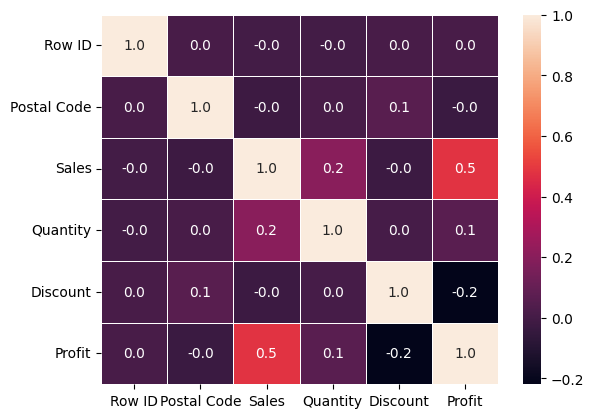

In [ ]:
plot = sns.heatmap(correlacao, annot = True, fmt=".1f", linewidths=.6)
plot

#Existem outliers nos dados? (Boxplots podem ajudar a identificar).


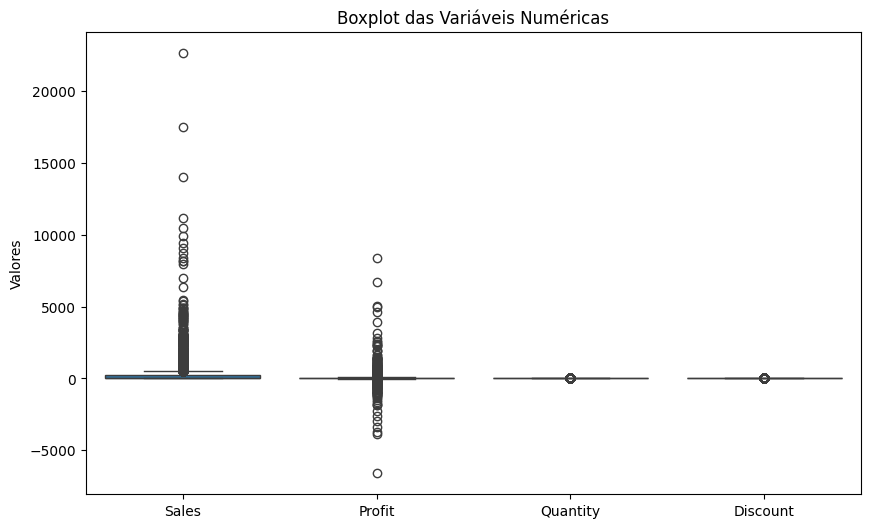

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[['Sales','Profit','Quantity','Discount']])
plt.title('Boxplot das Variáveis Numéricas')
plt.ylabel('Valores')
plt.show()

# Os dados mostram diferenças entre grupos? (Exemplo: Salários médios por gênero)



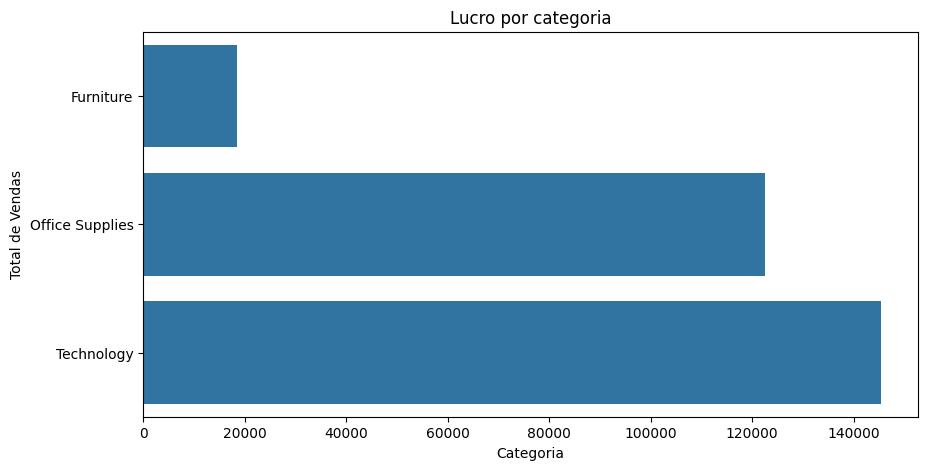

In [39]:
lucro_categoria = df.groupby('Category')['Profit'].sum()
plt.figure(figsize=(10,5))
sns.barplot(x=lucro_categoria.values, y=lucro_categoria.index)
plt.title('Lucro por categoria')
plt.xlabel('Categoria')
plt.ylabel('Total de Vendas')
plt.show()


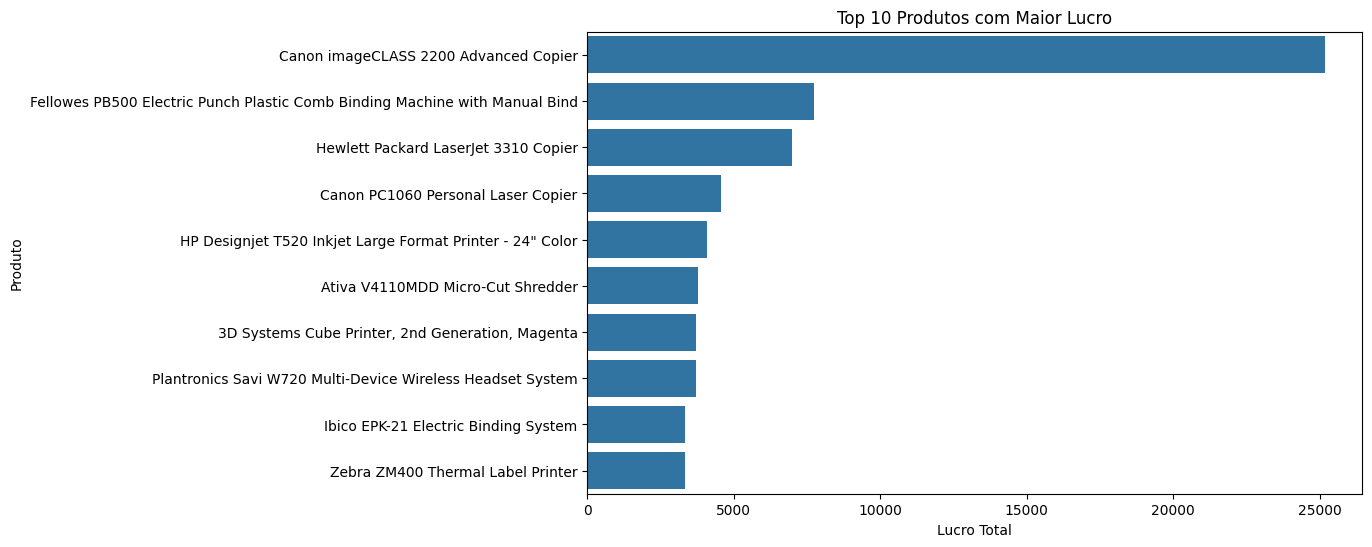

In [33]:
top10_produtos = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top10_produtos.values, y=top10_produtos.index)
plt.title('Top 10 Produtos com Maior Lucro')
plt.xlabel('Lucro Total')
plt.ylabel('Produto')
plt.show()

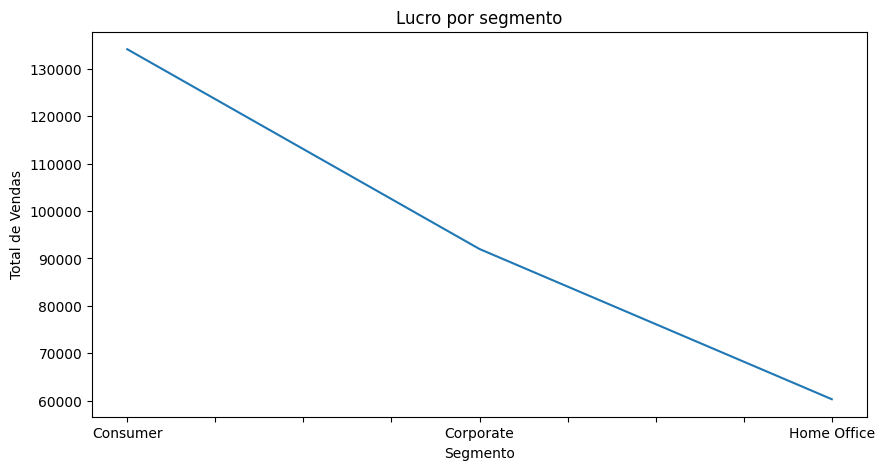

In [36]:
lucro_segmento = df.groupby('Segment')['Profit'].sum()
plt.figure(figsize=(10,5))
lucro_segmento.plot()
plt.title('Lucro por segmento')
plt.xlabel('Segmento')
plt.ylabel('Total de Vendas')
plt.show()

#Como os dados se comportam ao longo do tempo? (Se houver uma variável temporal)

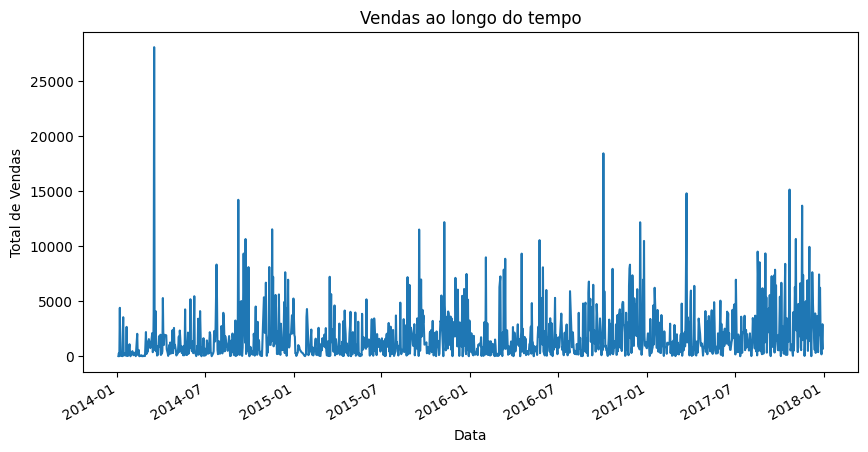

In [ ]:
sales_time = df.groupby('Order Date')['Sales'].sum()
plt.figure(figsize=(10,5))
sales_time.plot()
plt.title('Vendas ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Total de Vendas')
plt.show()

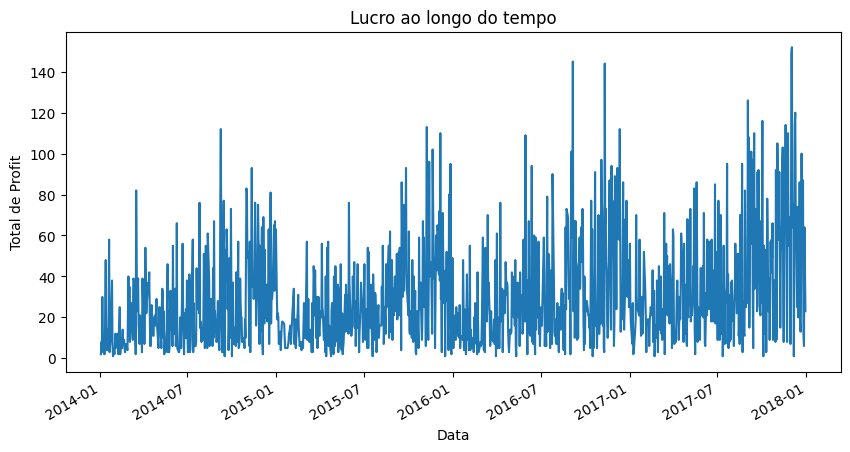

In [ ]:
profit_time = df.groupby('Order Date')['Quantity'].sum()
plt.figure(figsize=(10,5))
profit_time.plot()
plt.title('Quantidades vendidas ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Total de quantidades vendidas')
plt.show()